# Self-Check and Preparation

Welcome! This notebook teaches you how to allocate a limited inference budget between two strategies: **search** (generate many candidates and vote) and **verification** (generate candidates and have the model score them).

Before you start, complete a 3-question self-check to make sure you have the prerequisite knowledge. Answer each question **in your own words first**, then expand the answer block to check yourself.

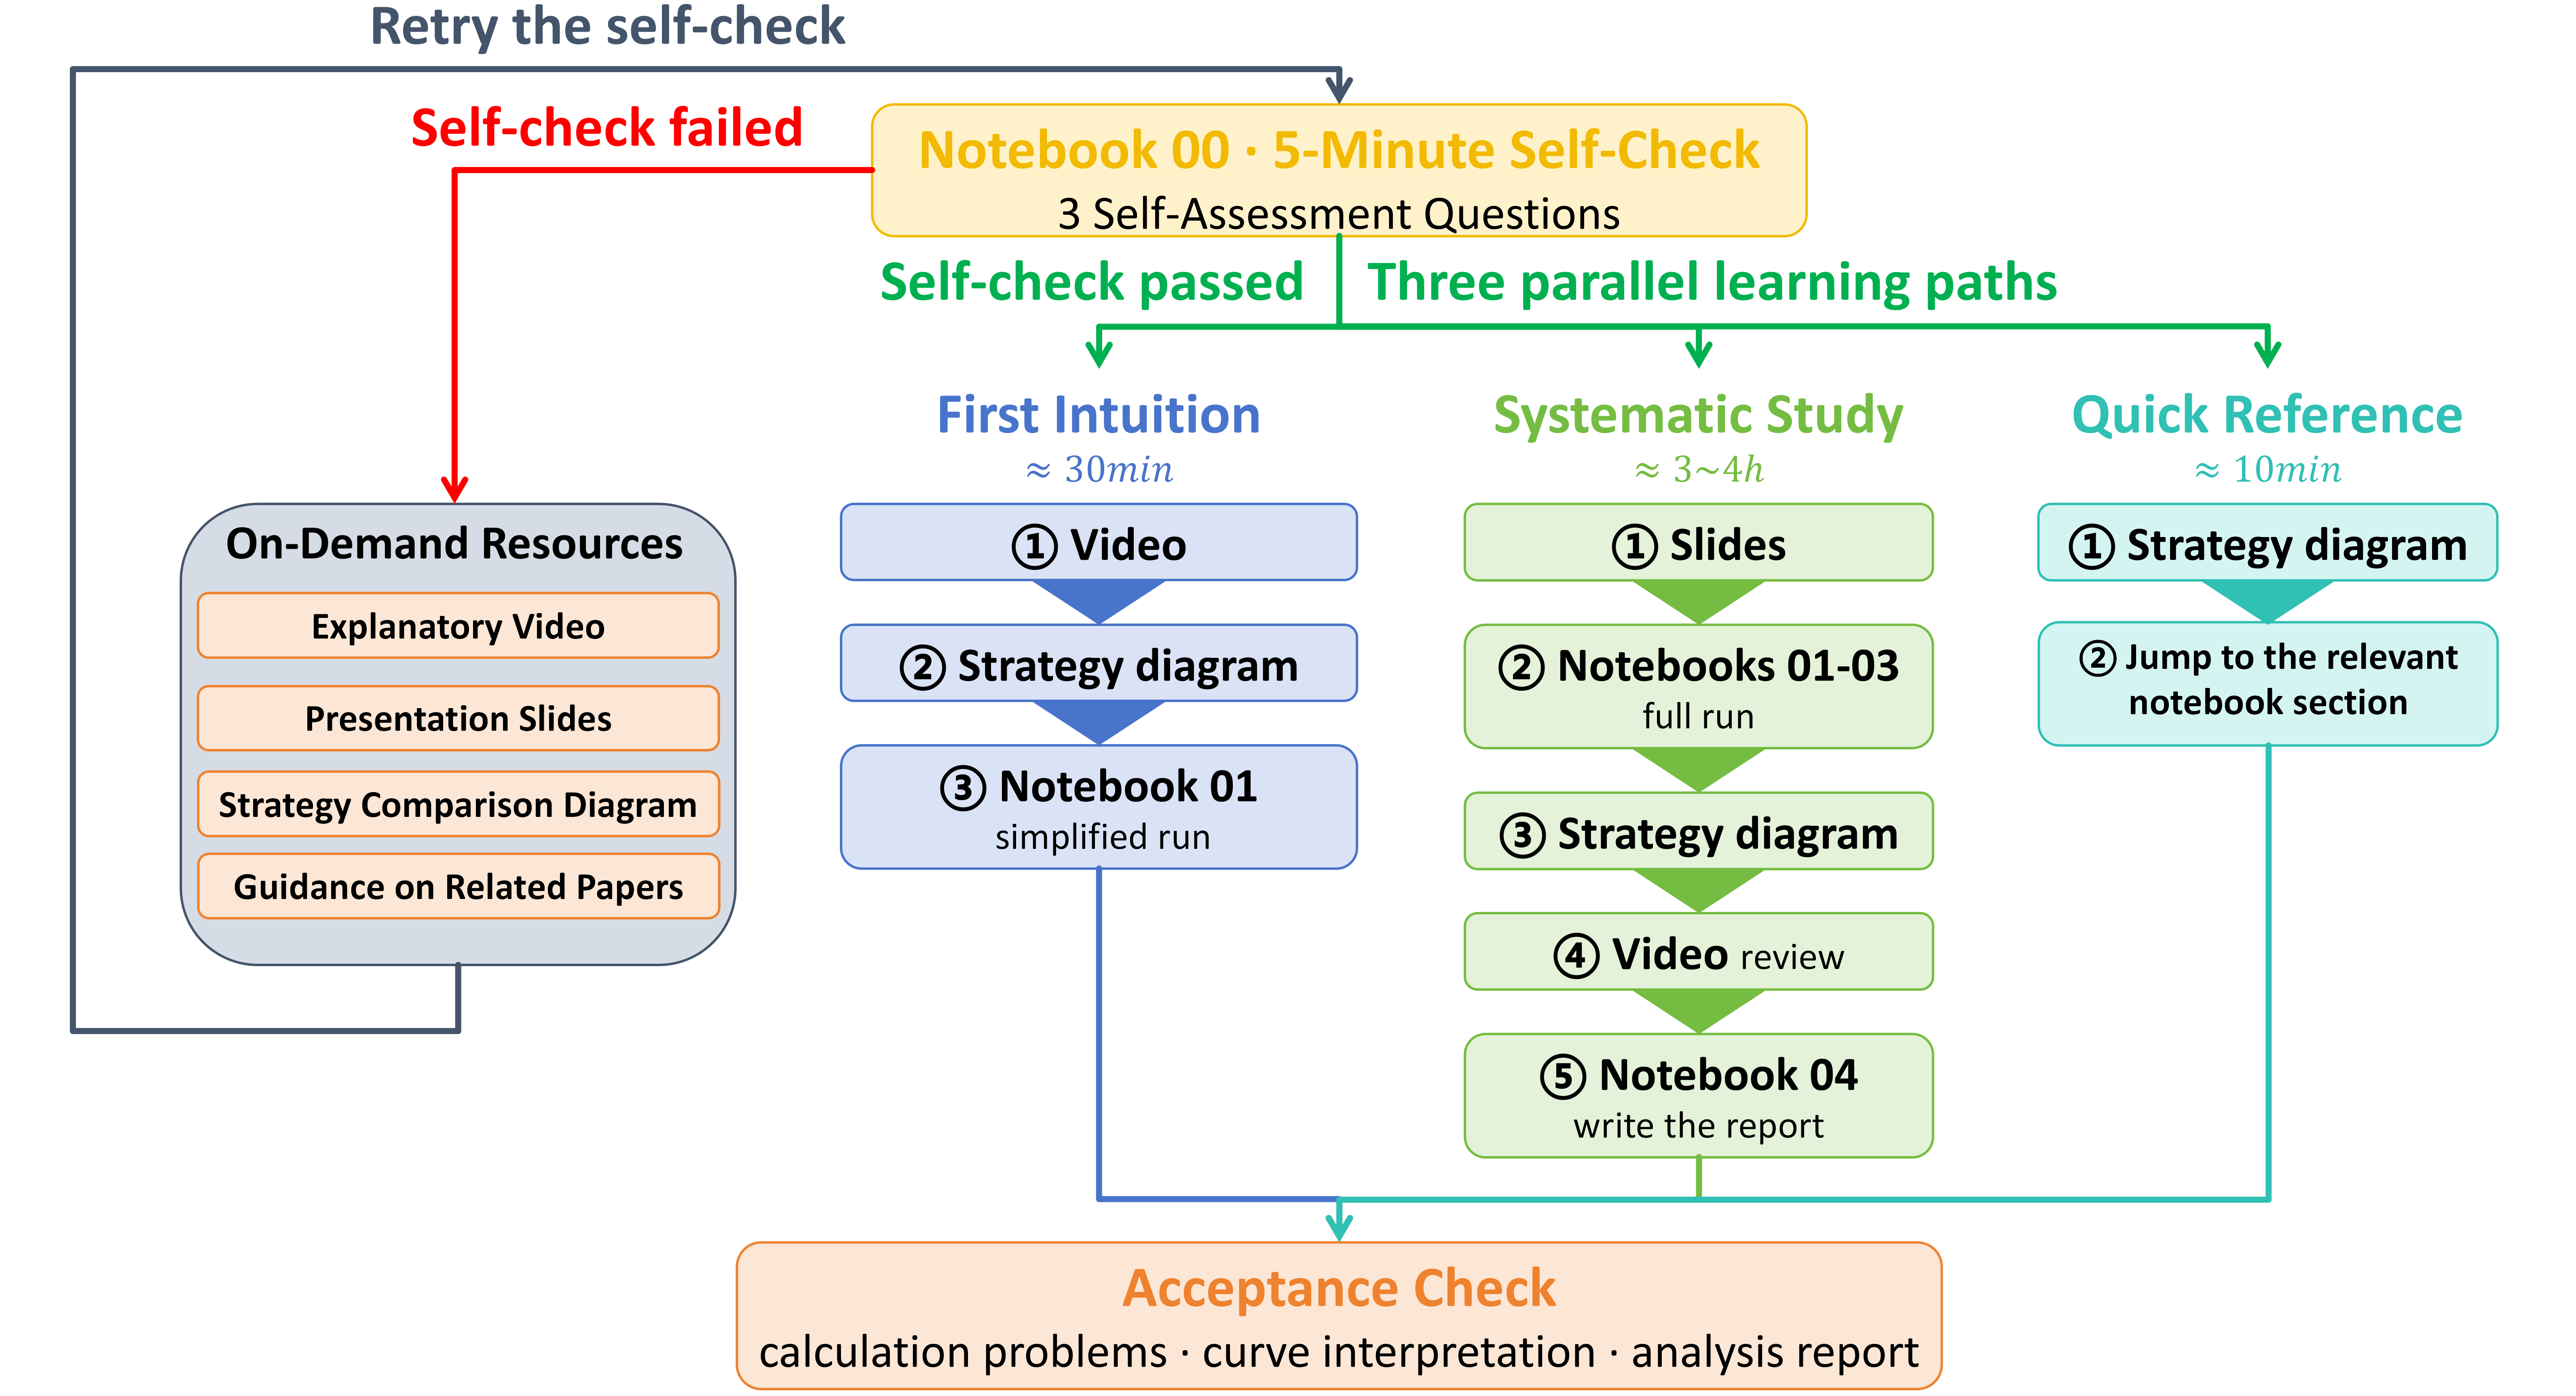

*Learning path overview: the self-check is the entry point. If it fails, use the on-demand resources on the left (video, slides, strategy diagram, papers) and retry; if it passes, follow one of three parallel paths (intuition-first, systematic study, quick reference) to the acceptance check.*

---

## How to use this notebook

1. Answer the 3 self-check questions below **without looking at the answers**.
2. Expand each answer block to verify your reasoning.
3. If you did not pass the self-check, review the supplementary materials (the self-check explanations) listed in the learning path; for the key references, see the Guidance on Related Papers node. Then retry the self-check before continuing.
4. When the self-check passes, proceed to `01_budget_efficiency.ipynb`.


---

## Self-Check Question 1: LLM Architecture and Autoregressive Decoding

> **Why does an LLM need to "move" (read) all of its parameters every time it generates a single token?**

Think about how autoregressive generation works before expanding the answer.

<details>
<summary><b>Show Answer 1</b></summary>

An LLM is **autoregressive**: to generate each token, it runs a **complete forward pass of the Transformer** (every layer and all parameters participate in the matrix computations), taking the full sequence of already-generated tokens as input. The output is a probability distribution over the next token. The weights themselves are fixed, but each forward pass must **read all parameters from GPU memory into the compute units**. Generating *T* tokens means *T* forward passes, so inference cost grows linearly with sequence length.

**Why this matters for this course:** this is the basis of the "single inference" unit: one inference = one LLM call. Voting itself consumes no inference calls. So with only 50 reasoning attempts, you are spending your budget one forward pass at a time.

**Self-check point:** you have the idea if you can explain in one sentence why generating a 100-token answer costs roughly 100 forward passes.

</details>


---

## Self-Check Question 2: Probability Basics

> **If each candidate answer is correct with probability p = 0.3, what is the probability that a majority vote over 3 independent candidates gives the correct answer?**

<details>
<summary><b>Show Answer 2</b></summary>

**21.6%**, *lower than the single-candidate 30%*: a majority needs at least two correct votes. 3 correct: 0.3³ = 2.7%; exactly 2 correct, 1 wrong: 3 × 0.3² × 0.7 = 18.9%. Total = 21.6%. **This is a pure binomial fact:** it does not depend on which wrong answers the model produced. Two wrong votes out of three are enough to fail the vote, whether the errors agree on one wrong answer or land on two different ones. Counting a tie as a failure (the Chernoff-style convention), p < 1/2 always makes majority voting worse than a single sample (21.6% < 30%), regardless of error concentration.

**Key teaching point: two separate mechanisms.**

1. **Binomial fact (concentration-independent):** as shown above, with p < 1/2 and ties counted as failures, majority voting is *mathematically guaranteed* to be worse than a single sample. This is why the Chernoff guarantee requires p > 1/2.
2. **Error-dispersion mechanism:** if the wrong answers are *concentrated* on the same wrong answer, the vote can elect that wrong answer (all the majority votes point the same way). If they are *dispersed* across many different wrong answers, the vote often ends in a tie. Under this course's first-occurrence rule, a tie picks the first candidate, so the correct-vote probability can rise to as much as **36.3%** (voting *helps*). Measured on the 100-problem, 3-seed headline run (roughly ±10 pp at 95% confidence at this size), search beats verification by +7.3 pp for Gemma-3-1B (p ≈ 0.37); the dispersion regime is a big part of why.

**Self-check point:** can you explain why voting hurts when p < 1/2 but helps when wrong answers are dispersed?

</details>


---

## Self-Check Question 3: LLM Reasoning Benchmarks

> **What is the difficulty difference between MATH and GSM8K?**

<details>
<summary><b>Show Answer 3</b></summary>

**GSM8K** contains elementary-to-middle-school math word problems (≈8K problems, short answers, one to a few reasoning steps). **MATH** is high-school-competition-level mathematics (12,500 problems, 5,000 in the held-out test set, spanning 7 subjects; multi-step reasoning, boxed symbolic answers). MATH is substantially harder. The same model's pass@1 is lower on MATH than on GSM8K.

**Why this matters:** task difficulty affects the single-candidate correctness probability p, the first variable in budget-allocation decisions: Experiment 3 (GSM8K migration) tests how a new task's p changes the optimal strategy.

**Self-check point:** try saying out loud which benchmark is harder and roughly why.

</details>



---

## Next Steps

- **Self-check passed** → continue to `01_budget_efficiency.ipynb` (Experiment 1: budget-accuracy curves).
- **Self-check failed** → review the supplementary materials and the other on-demand resources first: the five-minute explanatory video, presentation slides, the strategy comparison diagram, and the 5 key references (the Guidance on Related Papers node in the learning path). Then retry the self-check.
